PART IV: Elastic Net Regression using Gradient Descent
------------------
------------------

In [2]:
import pandas as pd
import numpy as np
from random import uniform
from math import sqrt
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('../data/diamond_preprocessed.csv')
df=df.drop('cut',axis=1)
df=df.drop('color',axis=1)
df=df.drop('clarity',axis=1)

In [4]:
df.describe()

,carat,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.792623,39521.990100,2.902669,61.752091,57.431713,3873.490749,5.729752,5.733730,3.537837
std,0.461506,5486.892971,1.325985,1.405688,2.173026,3921.933442,1.090754,1.124058,0.690119
min,0.200000,30000.000000,0.600000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,34780.000000,1.750000,61.100000,56.000000,978.000000,4.750000,4.740000,2.930000
50%,0.700000,39547.500000,2.910000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.030000,44252.000000,4.050000,62.500000,59.000000,5181.000000,6.510000,6.520000,4.020000
max,5.010000,48999.000000,5.200000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [5]:
# Defining the target variable Y
Y = df['price'].values.reshape(-1, 1)
# Creating input matrix X
X = df.drop(['price'], axis=1).values
# Spliting the dataset into training (80%) and testing (20%) sets
split_index = int(0.8 * len(df))
X_train, X_test = X[:split_index], X[split_index:]
Y_train, Y_test = Y[:split_index], Y[split_index:]


In [6]:
# d. Print the shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (43152, 8)
Shape of Y_train: (43152, 1)
Shape of X_test: (10788, 8)
Shape of Y_test: (10788, 1)


In [7]:
# Normalize the features
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [8]:
# elastic net loss function
def elasticnet_loss(X, Y, w, lambda1, lambda2):
    N = len(Y)
    residual = Y - X.dot(w)
    loss = (1/(2*N)) * np.sum(residual ** 2) + (lambda1 / 2) * np.sum(w ** 2) + lambda2 * np.sum(np.abs(w))
    return loss


In [9]:
#  Implementing Gradient Descent function
def gradient_descent_el(X, Y, w, lambda1, lambda2, alpha, max_iterations, threshold):
    N = len(Y)
    loss_history = []

    for i in range(max_iterations):
        residual = Y - X.dot(w)
        gradient = (-1/N) * X.T.dot(residual) + lambda1 * w + lambda2 * np.sign(w)
        w = w - alpha * gradient

        loss = elasticnet_loss(X, Y, w, lambda1, lambda2)
        loss_history.append(loss)

        if np.all(np.abs(gradient) < threshold):
            print(f"Converge at iteration {i}")
            break

        if i % 1000 == 0:
            print(f"Iteration {i}, Loss: {loss}")

    return w, loss_history

In [10]:
#  Weight initialization method
def rand_initialization_el(input_dim):
    return np.random.uniform(-0.001, 0.001, (input_dim, 1))

def zero_initialization_el(input_dim):
    return np.zeros((input_dim, 1))

def xavier_initialization_el(input_dim, output_dim):
    limit = sqrt(6 / (input_dim + output_dim))
    return np.random.uniform(-limit, limit, (input_dim, output_dim))

In [27]:
# Experimenting with different initializations and stopping criteria
lambda1, lambda2 = 0.001, 0.001
alpha = 0.01
max_iterations = 1000000
thresh = 0.1

initializations = [
    ("Random", rand_initialization_el(X_train.shape[1])),
    ("Zero", zero_initialization_el(X_train.shape[1])),
    ("Xavier", xavier_initialization_el(X_train.shape[1], 1))
]

for name, in_weights in initializations:
    print(f"\nTraining with {name} initialization:")
    final_weights, loss_history = gradient_descent_el(X_train, Y_train, in_weights, lambda1, lambda2, alpha, max_iterations, thresh)

    # Calculate and print final training loss
    final_train_loss = elasticnet_loss(X_train, Y_train, final_weights, lambda1, lambda2)
    print(f"Final training loss: {final_train_loss}")

    # Calculate and print test loss
    test_loss = elasticnet_loss(X_test, Y_test, final_weights, lambda1, lambda2)
    print(f"Test loss: {test_loss}")



Training with Random initialization:
Iteration 0, Loss: 17966641.899520136
Iteration 1000, Loss: 11349977.770409828
Iteration 2000, Loss: 11313582.738771474
Iteration 3000, Loss: 11303707.246063367
Iteration 4000, Loss: 11300908.2610403
Iteration 5000, Loss: 11300071.592159502
Iteration 6000, Loss: 11299806.10494565
Iteration 7000, Loss: 11299716.528674673
Iteration 8000, Loss: 11299684.4902898
Iteration 9000, Loss: 11299672.415468432
Iteration 10000, Loss: 11299667.651838694
Iteration 11000, Loss: 11299665.696065547
Iteration 12000, Loss: 11299664.86420287
Iteration 13000, Loss: 11299664.498943605
Converge at iteration 13717
Final training loss: 11299664.36842294
Test loss: 7226388.991536024

Training with Zero initialization:
Iteration 0, Loss: 17966645.972768378
Iteration 1000, Loss: 11349977.797920583
Iteration 2000, Loss: 11313582.749735672
Iteration 3000, Loss: 11303707.2504986
Iteration 4000, Loss: 11300908.262865191
Iteration 5000, Loss: 11300071.592924992
Iteration 6000, Loss

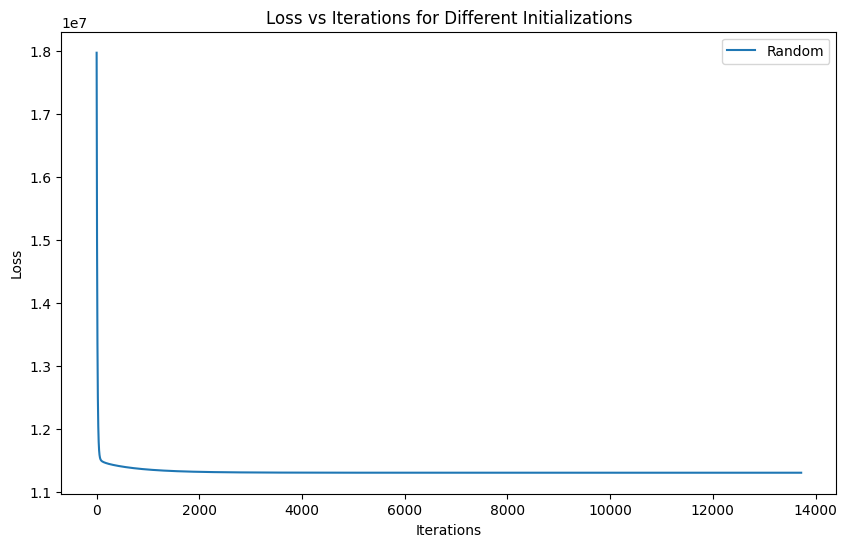

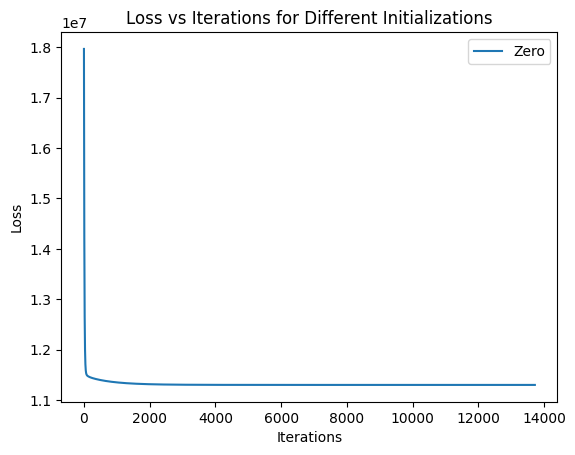

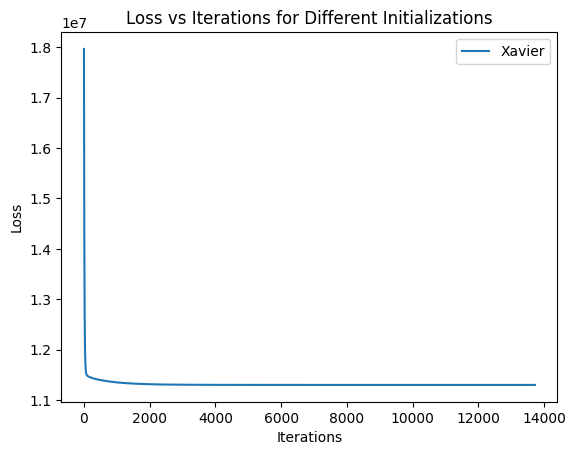

In [25]:
plt.figure(figsize=(10, 6))
for name, _ in initializations:
    plt.plot(loss_history, label=name)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title('Loss vs Iterations for Different Initializations')
    plt.legend()
    plt.show()


In [26]:
'''References: https://www.geeksforgeeks.org/lasso-vs-ridge-vs-elastic-net-ml/ https://www.mathworks.com/help/stats/lasso-and-elastic-net.html https://www.javatpoint.com/gradient-descent-in-machine-learning'''

'References: https://www.geeksforgeeks.org/lasso-vs-ridge-vs-elastic-net-ml/ https://www.mathworks.com/help/stats/lasso-and-elastic-net.html https://www.javatpoint.com/gradient-descent-in-machine-learning'